# **Potential Evapotranspiration: Comparing Methods and Calibrating the Priestley-Taylor Coefficient**

Priestley-Taylor, FAO-56 Penman-Monteith, and Hargreaves side by side, and what the Priestley-Taylor coefficient really represents.

## **Learning objectives**

By the end of this tutorial you will be able to:

- Compute the psychrometric constant, slope of the saturation vapor pressure curve, and latent heat of vaporization from air temperature.
- Implement Priestley-Taylor, FAO-56 reference ET, and Hargreaves PET and compare their seasonal cycles.
- Calibrate the Priestley-Taylor coefficient $\alpha$ against measured latent heat flux under wet conditions.
- Explain why a fixed $\alpha = 1.26$ can fail and how $\alpha$ varies with season and vegetation.

**Before you start:** Notebook 01 (energy balance). The Penman-Monteith tutorial at the repository root covers the full PM equation in depth.

## **Three ways to estimate potential evapotranspiration**

**Priestley-Taylor (1972).** Evaporation from a wet surface is mostly driven by available energy:

$$ \lambda PET_{PT} = \alpha \, \frac{\Delta}{\Delta + \gamma} (R_n - G), \qquad \alpha = 1.26 \qquad (1) $$

**FAO-56 Penman-Monteith reference ET** (Allen et al., 1998), for a well-watered grass of 0.12 m height:

$$ ET_0 = \frac{0.408\,\Delta (R_n - G) + \gamma \dfrac{900}{T + 273} u_2 (e_s - e_a)}{\Delta + \gamma (1 + 0.34 u_2)} \qquad (2) $$

**Hargreaves-Samani (1985).** Needs only temperature and extraterrestrial radiation $R_a$:

$$ PET_{HS} = 0.0023 \, (T_{mean} + 17.8) \sqrt{T_{max} - T_{min}} \; R_a \qquad (3) $$

with $R_a$ in mm day$^{-1}$ equivalent. Symbols: $\Delta$ slope of the saturation vapor pressure curve (kPa $^\circ$C$^{-1}$),
$\gamma$ psychrometric constant (kPa $^\circ$C$^{-1}$), $e_s - e_a$ vapor pressure deficit (kPa), $u_2$ wind speed at 2 m (m s$^{-1}$).

The methods differ in their data needs and in what they assume drives evaporation. Comparing them on one site shows
how much those assumptions matter.

**Site used in this tutorial:** US-Var (Vaira Ranch, California), an AmeriFlux grassland site with a Mediterranean climate: wet, mild winters and dry, hot summers. The daily file `daily_data_UA-Var_2000_2021.csv` contains gap-filled fluxes (LE, H, G), net radiation, meteorology, LAI, fPAR, GPP, and soil moisture (`theta_2`) for 2000-2021. Flux units are W m$^{-2}$ (daily means).

Daily maximum and minimum temperature come from Daymet (`daymet_US-Var_2000_2021.csv`).

## **Setup: packages and data**

The cell below loads the packages we need and defines a small helper that finds the sample data. If you are running inside the cloned repository it uses the local `sample_data/` folder; on Google Colab it downloads the files from GitHub.

In [1]:
import os, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.dpi'] = 100

BASE = "https://raw.githubusercontent.com/praghav444/CEE491-591-Process-Hydrology-Tutorials/main/sample_data/"

def get_data(fname):
    """Return a local path to a sample data file, downloading it from GitHub if needed."""
    for local in [os.path.join('..', '..', 'sample_data', fname), os.path.join('sample_data', fname)]:
        if os.path.exists(local):
            return local
    os.makedirs('sample_data', exist_ok=True)
    out = os.path.join('sample_data', fname)
    urllib.request.urlretrieve(BASE + fname, out)
    return out

files = ['daily_data_UA-Var_2000_2021.csv', 'daymet_US-Var_2000_2021.csv']
paths = {f: get_data(f) for f in files}
paths

{'daily_data_UA-Var_2000_2021.csv': '..\\..\\sample_data\\daily_data_UA-Var_2000_2021.csv',
 'daymet_US-Var_2000_2021.csv': '..\\..\\sample_data\\daymet_US-Var_2000_2021.csv'}

In [2]:
df = pd.read_csv(paths['daily_data_UA-Var_2000_2021.csv'])
df['Date'] = pd.to_datetime(df['DateTime']); df = df.set_index('Date').drop(columns='DateTime')
df = df.rename(columns={'LE_F_MDS': 'LE', 'H_F_MDS': 'H', 'G_F_MDS': 'G', 'NETRAD': 'Rn', 'TA_F': 'TA',
                        'VPD_F': 'VPD_hPa', 'SW_IN_F': 'SW_IN', 'WS_F': 'WS', 'PA_F': 'PA'})
dm = pd.read_csv(paths['daymet_US-Var_2000_2021.csv'], parse_dates=['Date']).set_index('Date')
df = df.join(dm[['Tmax_C', 'Tmin_C', 'P_mm']])
df['VPD'] = df['VPD_hPa'] / 10.0           # kPa
lat = 38.4133                               # US-Var latitude (deg)
z_wind = 2.5                                # wind measurement height (m)
df[['TA', 'Tmax_C', 'Tmin_C', 'VPD', 'WS', 'Rn', 'G', 'LE']].describe().round(2)

,TA,Tmax_C,Tmin_C,VPD,WS,Rn,G,LE
count,8036.00,8030.00,8030.00,8036.00,8036.00,8036.00,8036.00,8036.00
mean,16.08,24.33,10.06,1.08,1.33,87.18,0.92,23.68
std,6.75,8.81,5.44,0.89,0.44,59.11,8.14,25.02
min,0.95,4.46,-5.53,0.00,0.44,-133.91,-69.00,-2.43
25%,10.53,16.75,5.85,0.36,1.10,38.29,-4.59,3.82
50%,15.37,23.64,9.70,0.78,1.25,80.08,0.18,15.61
75%,21.58,32.27,14.27,1.65,1.40,137.58,6.62,33.10
max,36.24,44.98,29.30,4.60,5.54,230.48,29.78,126.29


## **Step 1: Meteorological helper functions**

These are the standard FAO-56 formulas. Keep them; you will reuse them in later tutorials.

In [3]:
def es_kPa(T):                    # saturation vapor pressure (kPa), T in degC
    return 0.6108 * np.exp(17.27 * T / (T + 237.3))

def delta_kPa_per_C(T):           # slope of the saturation vapor pressure curve
    return 4098 * es_kPa(T) / (T + 237.3) ** 2

def latent_heat_MJ_kg(T):
    return 2.501 - 0.002361 * T

def gamma_kPa_per_C(P_kPa, T):    # psychrometric constant
    return 0.000665 * P_kPa      # FAO-56 simplification (cp * P / (0.622 * lambda))

def extraterrestrial_radiation(doy, lat_deg):
    """Daily extraterrestrial radiation Ra (MJ m-2 day-1), FAO-56 eqs 21-25."""
    lat = np.deg2rad(lat_deg)
    dr = 1 + 0.033 * np.cos(2 * np.pi * doy / 365)
    dec = 0.409 * np.sin(2 * np.pi * doy / 365 - 1.39)
    ws = np.arccos(-np.tan(lat) * np.tan(dec))
    return (24 * 60 / np.pi) * 0.0820 * dr * (ws * np.sin(lat) * np.sin(dec) + np.cos(lat) * np.cos(dec) * np.sin(ws))

W_to_MJ_day = 0.0864              # 1 W m-2 sustained for a day = 0.0864 MJ m-2

## **Step 2: The three PET estimates**

In [4]:
T = df['TA']; D = delta_kPa_per_C(T); g = gamma_kPa_per_C(df['PA'], T); lam = latent_heat_MJ_kg(T)
AE = (df['Rn'] - df['G']) * W_to_MJ_day          # available energy, MJ m-2 day-1

# (1) Priestley-Taylor, alpha = 1.26
df['PET_PT'] = 1.26 * D / (D + g) * AE / lam                            # mm/day

# (2) FAO-56 reference ET (wind adjusted from 2.5 m to 2 m with the FAO log profile)
u2 = df['WS'] * 4.87 / np.log(67.8 * z_wind - 5.42)
df['ET0_FAO'] = (0.408 * D * AE + g * 900 / (T + 273) * u2 * df['VPD']) / (D + g * (1 + 0.34 * u2))

# (3) Hargreaves-Samani (Ra converted from MJ m-2 day-1 to mm day-1 with 0.408)
Ra = extraterrestrial_radiation(df.index.dayofyear.values, lat)
df['PET_HS'] = 0.0023 * (T + 17.8) * np.sqrt((df['Tmax_C'] - df['Tmin_C']).clip(lower=0)) * 0.408 * Ra

# measured ET for comparison
df['ET_obs'] = df['LE'] * 86400 / (lam * 1e6)
df[['PET_PT', 'ET0_FAO', 'PET_HS', 'ET_obs']].describe().round(2)

,PET_PT,ET0_FAO,PET_HS,ET_obs
count,8036.00,8036.00,8030.00,8036.00
mean,2.52,2.87,3.78,0.83
std,1.71,1.72,2.21,0.88
min,-3.19,-1.55,0.59,-0.09
25%,1.04,1.31,1.68,0.14
50%,2.27,2.70,3.42,0.55
75%,3.95,4.36,5.77,1.16
max,6.90,7.58,9.62,4.44


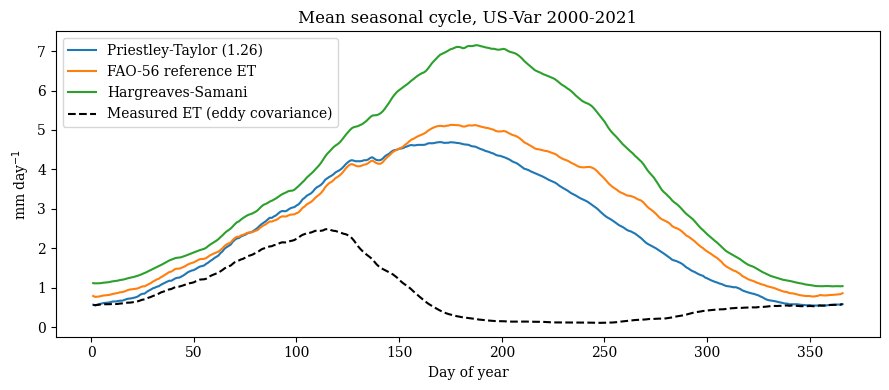

In [5]:
clim = df[['PET_PT', 'ET0_FAO', 'PET_HS', 'ET_obs']].groupby(df.index.dayofyear).mean().rolling(15, center=True, min_periods=1).mean()
fig, ax = plt.subplots(figsize=(9, 4))
for c, lab, st in [('PET_PT', 'Priestley-Taylor (1.26)', '-'), ('ET0_FAO', 'FAO-56 reference ET', '-'),
                   ('PET_HS', 'Hargreaves-Samani', '-'), ('ET_obs', 'Measured ET (eddy covariance)', 'k--')]:
    ax.plot(clim.index, clim[c], st, label=lab)
ax.set_xlabel('Day of year'); ax.set_ylabel('mm day$^{-1}$'); ax.set_title('Mean seasonal cycle, US-Var 2000-2021'); ax.legend(); plt.tight_layout()

**What to notice.** All three PET methods peak in summer with the radiation, but measured ET peaks in spring and then
falls far below PET once the soil dries. PET is the *demand*; actual ET is limited by *supply* in summer. The gap between
the curves is exactly what drought indices such as the evaporative stress ratio (ET/PET) use.

The methods also disagree with each other. FAO-56 includes wind and vapor pressure deficit and runs higher in the dry,
windy summer; Hargreaves uses only temperature and is smoother.

## **Step 3: Calibrate the Priestley-Taylor coefficient**

The value $\alpha = 1.26$ was derived for wet surfaces with minimal advection. On days when water is not limiting, measured ET should equal PET, so we can solve for $\alpha$ from the data:

$$ \alpha = \frac{\lambda ET_{obs}}{\dfrac{\Delta}{\Delta + \gamma}(R_n - G)} $$

We select wet days (high soil moisture, green canopy) and look at how $\alpha$ behaves by month.

882 wet, green days out of 8036
      median  count
Date               
1       0.70     71
2       0.83    246
3       0.87    334
4       0.85    184
5       0.71     24
6       0.59      5
10      0.94      1
11      0.93     13
12      0.60      4


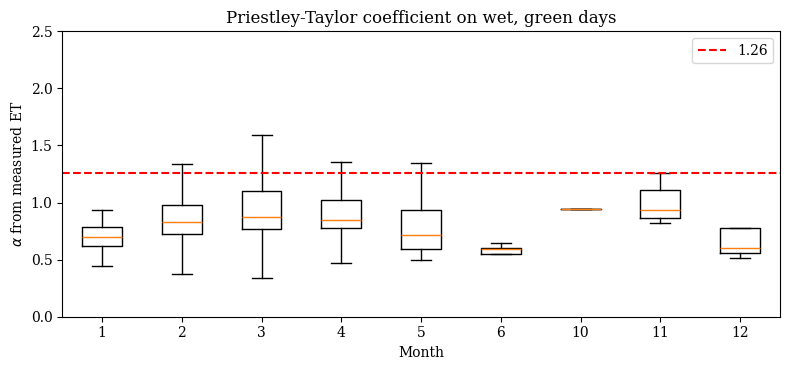

In [6]:
equil = D / (D + g) * AE / lam                               # equilibrium evaporation, mm/day
df['alpha_obs'] = df['ET_obs'] / equil
wet = (df['theta_2'] > 0.25) & (df['LAI'] > 0.8) & (equil > 1.0) & (df['ET_obs'] > 0)
print(f'{wet.sum()} wet, green days out of {len(df)}')
alpha_month = df.loc[wet].groupby(df.loc[wet].index.month)['alpha_obs'].agg(['median', 'count'])
print(alpha_month.round(2))

months_present = sorted(df.loc[wet].index.month.unique())
data = [df.loc[wet & (df.index.month == m), 'alpha_obs'].dropna().values for m in months_present]
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.boxplot(data, tick_labels=months_present, showfliers=False)
ax.axhline(1.26, color='r', ls='--', label='1.26'); ax.set_ylim(0, 2.5)
ax.set_xlabel('Month'); ax.set_ylabel(r'$\alpha$ from measured ET'); ax.set_title('Priestley-Taylor coefficient on wet, green days')
ax.legend(); plt.tight_layout()

Even on wet, green days $\alpha$ is not a constant. It changes with the season and the state of the vegetation, and at
many sites it is well below 1.26 because the surface is never fully wet. This is why recent work parameterizes
$\alpha$ dynamically from observable drivers (temperature, vapor pressure deficit, vegetation) rather than fixing it.

## **Step 4: Does a calibrated $\alpha$ help?**

Use the monthly median $\alpha$ from wet days to recompute PET, then compare PET methods on wet days only, where PET should match ET.

In [7]:
alpha_by_month = alpha_month['median'].reindex(range(1, 13)).interpolate().bfill().ffill()
df['PET_PT_cal'] = df.index.month.map(alpha_by_month).values * equil

def score(pred, obs):
    m = pred.notna() & obs.notna()
    rmse = np.sqrt(np.mean((pred[m] - obs[m]) ** 2)); bias = np.mean(pred[m] - obs[m])
    r2 = np.corrcoef(pred[m], obs[m])[0, 1] ** 2
    return pd.Series({'RMSE (mm/d)': rmse, 'Bias (mm/d)': bias, 'R2': r2})

res = pd.DataFrame({m: score(df.loc[wet, m], df.loc[wet, 'ET_obs']) for m in ['PET_PT', 'PET_PT_cal', 'ET0_FAO', 'PET_HS']}).T
print('Wet-day comparison against measured ET:'); print(res.round(2))

Wet-day comparison against measured ET:
            RMSE (mm/d)  Bias (mm/d)    R2
PET_PT             1.04         0.81  0.67
PET_PT_cal         0.42        -0.05  0.70
ET0_FAO            0.91         0.72  0.68
PET_HS             1.04         0.90  0.69


## **Exercises**

**Exercise 1.** Change the wet-day criteria (for example `theta_2 > 0.3` or `LAI > 1.2`) and see how the monthly $\alpha$ values change. Which criterion gives the most stable $\alpha$?

**Exercise 2.** Compute the evaporative stress ratio $ESR = ET_{obs}/PET$ with each of the three PET methods and plot the 2013-2015 drought. Does the choice of PET method change the drought signal?

**Exercise 3.** Hargreaves needs a local calibration in many climates. Fit a single multiplier so that mean Hargreaves PET matches mean FAO-56 ET0, and report the value.

**Exercise 4.** Repeat Step 2 for the one-year file `Sample_data.csv` (columns TA, Rn, G, WS, RH, PA). You will need to compute VPD from relative humidity: $VPD = e_s(T)(1 - RH/100)$.

## **References**

- Priestley, C. H. B., & Taylor, R. J. (1972). On the assessment of surface heat flux and evaporation using large-scale parameters. *Monthly Weather Review*, 100, 81-92.
- Allen, R. G., Pereira, L. S., Raes, D., & Smith, M. (1998). *Crop evapotranspiration: Guidelines for computing crop water requirements.* FAO Irrigation and Drainage Paper 56.
- Hargreaves, G. H., & Samani, Z. A. (1985). Reference crop evapotranspiration from temperature. *Applied Engineering in Agriculture*, 1, 96-99.
- Raghav, P., & Kumar, M. (2026). Dynamic parameterization of the Priestley-Taylor coefficient for more accurate potential evapotranspiration estimation in ungauged regions. *Environmental Research Letters*.